# Training

## Konfigurasi Global

In [1]:
IS_USING_FFT_DOMAIN = True
WINDOW_SIZE = 128

ROOT_PROJECT_DATASET = "/home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing"
BEARING_VARIATION_FOLDER = ("bearing_1", )

BEARING_LIFESPAN_TIME = 392_275
TURNING_POINT_TIME = 290000

MAIN_BEARING = BEARING_VARIATION_FOLDER[0] # Pilih bearing utama untuk analisis

# FFT Domain
# 0 - 1280 Hz
FREQUENCY_MIN, FREQUENCY_MAX = 220, 260
SAMPLING_RATE = 2560

In [2]:
'''
HI : BLACK - Full line
TP : RED - Full line
X : BLUE - Full Line 
Y : ORANGE - Full line 
Z : GREEN - Full line
'''

PLOT_STYLES = {
    "HI": {"color": "black", "linestyle": "-"},
    "HI_PRED": {"color": "gold", "linestyle": "--"},
    "TP": {"color": "red", "linestyle": "-"},
    "TP_PRED": {"color": "red", "linestyle": "--"},
    "X": {"color": "blue", "linestyle": "-"},
    "Y": {"color": "orange", "linestyle": "-"},
    "Z": {"color": "green", "linestyle": "-"},
}

## Import

In [3]:
import os
import glob
import re
import time

import numpy as np
from numpy.fft import rfft, rfftfreq

import pandas as pd

import dask.dataframe as dd
import dask.array as da
from dask.diagnostics.progress import ProgressBar

import torch
import torch.optim as optim
import torch.nn as nn

from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

import plotly.graph_objs as go
import plotly.offline as pyo

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import seaborn as sns

from tqdm import tqdm  # Import tqdm for progress bar

import gc

## Helper Function

In [4]:
def temp_output_bearing_root(bearing_name: str) -> str:
    return f"{ROOT_PROJECT_DATASET}/{bearing_name}"

def bearing_file_full_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_full.parquet"

def bearing_file_raw_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_raw.parquet"

def export_dataset_root(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/datasets"

def export_dataset_name_for_fft_base(bearing_name: str) -> str:
    return f"{export_dataset_root(bearing_name)}/fft"

def export_dataset_name_for_raw_base(bearing_name: str) -> str:
    return f"{export_dataset_root(bearing_name)}/raw"


def bearing_file_fft_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_fft.parquet"

def series_health_index(t: float, Tcp: float, Tf: float) -> float:
    """Calculate the health index based on time, Tcp, and Tf.
    Args:
        t (float): current time
        Tcp (float): turning point time
        Tf (float): max time

    Returns:
        float: health index value between 0 (Broken) and 1 (Good)
    """
    return 1 - ( max((t - Tcp), 0) / (Tf - Tcp) )

def health_index_to_rul(health_index, Tf: float) -> float:
    """
    Convert health index (HI) to RUL.
    HI: 1.0 = new, 0.0 = failed
    max_rul: maximum RUL (e.g., total life in seconds or cycles)
    """
    return np.clip(health_index, 0, 1) * Tf

def create_sequences(X, y, window_size=10):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:(i + window_size)])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

def rmse_score(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def relative_prediction_error(y_true, y_pred):
    """Relative Prediction Error (RPE) as a percentage"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def accuracy_score(y_true, y_pred):
    """
    Calculate the accuracy score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: Accuracy score (between 0 and 1).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    """
    Calculate the precision score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: Precision score (between 0 and 1).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    false_positive = np.sum((y_true == 0) & (y_pred == 1))
    return true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0.0

def recall_score(y_true, y_pred):
    """
    Calculate the recall score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: Recall score (between 0 and 1).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    false_negative = np.sum((y_true == 1) & (y_pred == 0))
    return true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0

def f1_score(y_true, y_pred):
    """
    Calculate the F1 score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: F1 score (between 0 and 1).
    """
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def confusion_matrix(y_true, y_pred):
    """
    Calculate the confusion matrix for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        np.ndarray: Confusion matrix.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    classes = np.unique(np.concatenate((y_true, y_pred)))
    matrix = np.zeros((len(classes), len(classes)), dtype=int)
    
    for i, true_label in enumerate(classes):
        for j, pred_label in enumerate(classes):
            matrix[i, j] = np.sum((y_true == true_label) & (y_pred == pred_label))
    
    return matrix

def asymmetric_loss_scoring_function(y_pred, y_true, a=10, b=13):
    """
    Asymmetric loss for regression (PyTorch version).
    Penalizes late predictions more than early ones using an exponential function.
    y = exp(-(y_pred - y_true)/a) - 1, if early (y_pred < y_true)
    y = exp((y_pred - y_true)/b) - 1, if late (y_pred >= y_true)
    """
    diff = y_pred - y_true
    loss = torch.where(
        diff < 0,
        torch.exp(-diff / a) - 1,   # Early prediction (small penalty)
        torch.exp(diff / b) - 1     # Late prediction (large penalty)
    )
    return loss.mean()

## A. Load Dataset

In [5]:
# Load Training Dataset
if not IS_USING_FFT_DOMAIN:
    TRAIN_DATA_LOC = f"{export_dataset_name_for_raw_base(MAIN_BEARING)}_train_data.parquet"
    TEST_DATA_LOC = f"{export_dataset_name_for_raw_base(MAIN_BEARING)}_test_data.parquet"
else:
    TRAIN_DATA_LOC = f"{export_dataset_name_for_fft_base(MAIN_BEARING)}_{FREQUENCY_MIN}_{FREQUENCY_MAX}_train_data.parquet"
    TEST_DATA_LOC = f"{export_dataset_name_for_fft_base(MAIN_BEARING)}_{FREQUENCY_MIN}_{FREQUENCY_MAX}_test_data.parquet"

TRAIN_DATA = pd.read_parquet(f"{TRAIN_DATA_LOC}")
TEST_DATA = pd.read_parquet(f"{TEST_DATA_LOC}")

print(f"Train (loc: {TRAIN_DATA_LOC}) shape: ({TRAIN_DATA.shape[0]}, {TRAIN_DATA.shape[1]})")
print(f"Test (loc: {TEST_DATA_LOC}) shape: ({TEST_DATA.shape[0]}, {TEST_DATA.shape[1]})")

Train (loc: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_220_260_train_data.parquet) shape: (653, 5)
Test (loc: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_220_260_test_data.parquet) shape: (652, 5)


## B. Normalization

In [6]:
FEATURES = ["FFT_X", "FFT_Y", "FFT_Z"] if IS_USING_FFT_DOMAIN else ["X", "Y", "Z"]
TARGET = "health_index"

fft_scaler = MinMaxScaler()

X_train = fft_scaler.fit_transform(TRAIN_DATA[FEATURES])
y_train = TRAIN_DATA[TARGET].values

X_test = fft_scaler.transform(TEST_DATA[FEATURES])
y_test = TEST_DATA[TARGET].values

## C. Create Sequences Windows

In [7]:
X_train_seq, y_train_seq = create_sequences(X_train, y_train, window_size=WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, window_size=WINDOW_SIZE)

print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

X_train_seq shape: (525, 128, 3), y_train_seq shape: (525,)
X_test_seq shape: (524, 128, 3), y_test_seq shape: (524,)


## D. Convert to Tensor

In [8]:
X_train_tensor = torch.from_numpy(X_train_seq).float()
y_train_tensor = torch.from_numpy(y_train_seq).float().view(-1, 1)

X_test_tensor = torch.from_numpy(X_test_seq).float()
y_test_tensor = torch.from_numpy(y_test_seq).float().view(-1, 1)

y_hi_train = (y_train_seq < 1.0).astype(float)
y_hi_train = torch.from_numpy(y_hi_train).float().view(-1, 1)

y_hi_test = (y_test_seq < 1.0).astype(float)
y_hi_test = torch.from_numpy(y_hi_test).float().view(-1, 1)

## E. Plot Data before Training for Visualization

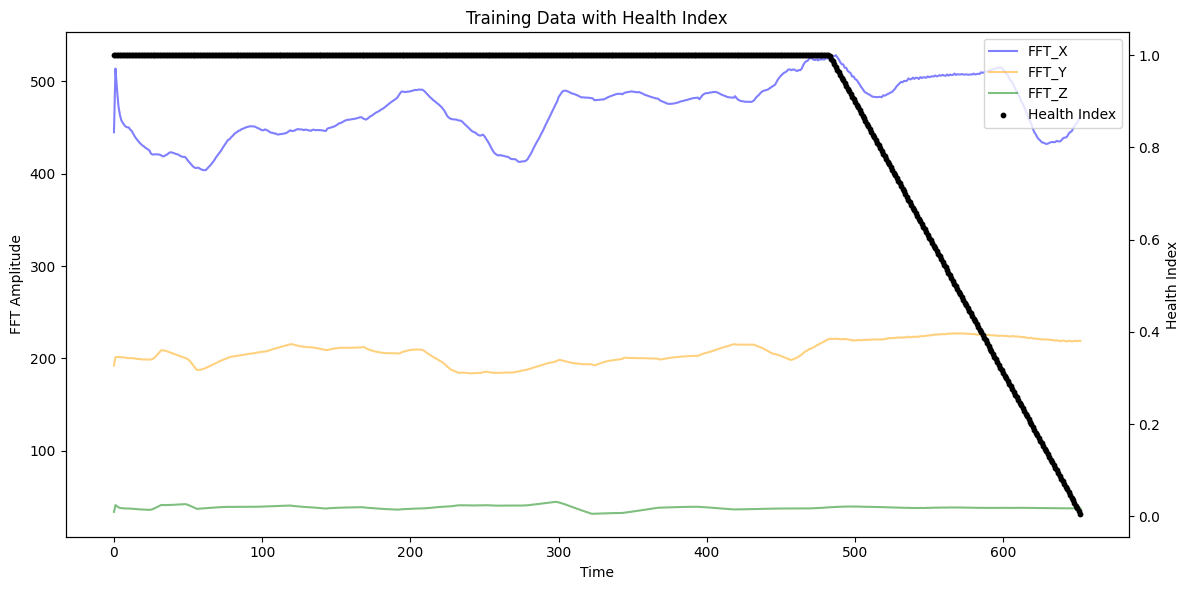

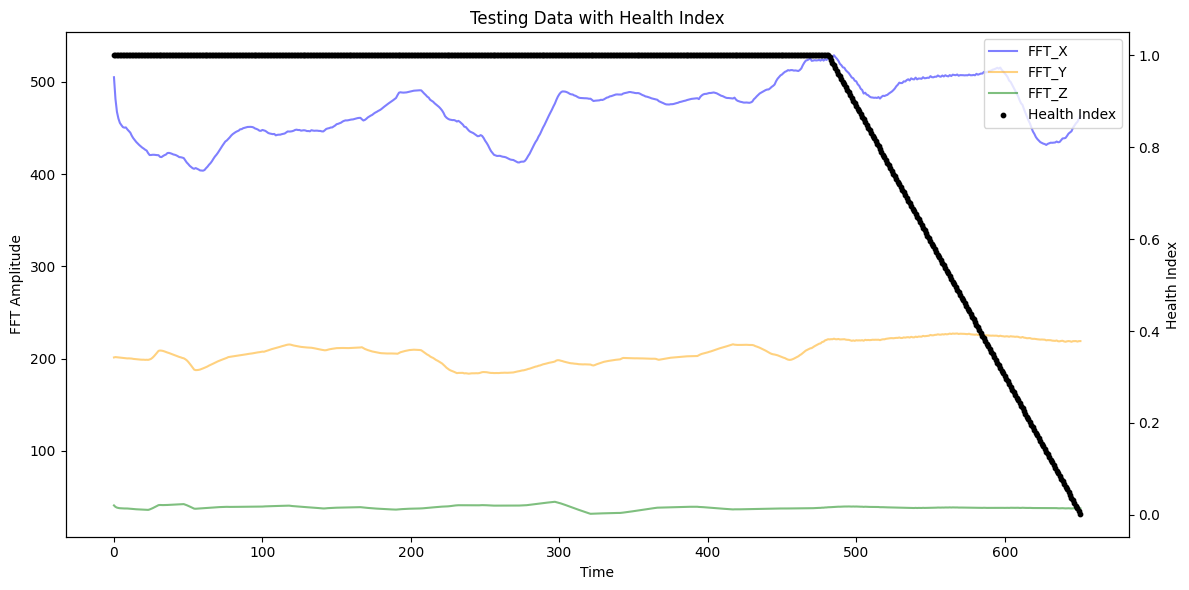

In [9]:
def plot_data_with_health_index(data, title="Data with Health Index"):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    # Plot FFT features on the primary y-axis
    ax1.plot(data.index, data[FEATURES[0]], label=FEATURES[0], alpha=0.5, **PLOT_STYLES["X"])
    ax1.plot(data.index, data[FEATURES[1]], label=FEATURES[1], alpha=0.5, **PLOT_STYLES["Y"])
    ax1.plot(data.index, data[FEATURES[2]], label=FEATURES[2], alpha=0.5, **PLOT_STYLES["Z"])
    ax1.set_xlabel("Time")
    ax1.set_ylabel("FFT Amplitude")
    ax1.legend(loc="upper left")

    # Plot Health Index on the secondary y-axis
    ax2 = ax1.twinx()
    ax2.scatter(data.index, data[TARGET], label='Health Index', s=10, **PLOT_STYLES["HI"])
    ax2.set_ylabel("Health Index", color=PLOT_STYLES["HI"]["color"])
    ax2.tick_params(axis='y', labelcolor=PLOT_STYLES["HI"]["color"])

    # Combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

    plt.title(title)
    plt.tight_layout()
    plt.show()
    
plot_data_with_health_index(TRAIN_DATA, title="Training Data with Health Index")
plot_data_with_health_index(TEST_DATA, title="Testing Data with Health Index")

## F. Define Model

### 1. HI Model (GRU)

In [10]:
class HealthIndexGRU(nn.Module):
    def __init__(self, input_size=3, hidden_layer_size=50, num_layers=2, output_size=1, dropout_rate=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        gru_out, _ = self.gru(input_seq)
        last_time_step_out = gru_out[:, -1, :]
        dropped = self.dropout(last_time_step_out)
        predictions = self.linear(dropped)
        return predictions

## G. Training

### 1. Configuration

In [11]:
# Hyperparameters Configuration

EPOCHS = 2000 # Number of epochs for training
PATIENCE = 150 # Early stopping patience

# Health Index Model
HEALTH_INDEX_HIDDEN_LAYER_SIZE = 26
HEALTH_INDEX_NUM_LAYERS = 2

HEALTH_INDEX_DROPOUT_RATE = 0.1
HEALTH_INDEX_LEARNING_RATE = 0.02
HEALTH_INDEX_BETAS = (0.9, 0.999)  # Adam optimizer parameters, Only edit the second value
HEALTH_INDEX_EPSILON = 1e-8  # Adam optimizer epsilon

# Training strategy parameters
USE_DYNAMIC_CPD = True  # Set to False to use only ground truth
WARMUP_EPOCHS = 0  # Use ground truth for first N epochs
TRANSITION_EPOCHS = 0  # Gradual transition period
CPD_CONFIDENCE_THRESHOLD = 0.7  # Minimum confidence to use CPD prediction


_func = export_dataset_name_for_fft_base if IS_USING_FFT_DOMAIN else export_dataset_name_for_raw_base

### 2. Training

In [12]:
hi_model = HealthIndexGRU(input_size=3, hidden_layer_size=HEALTH_INDEX_HIDDEN_LAYER_SIZE, num_layers=HEALTH_INDEX_NUM_LAYERS, dropout_rate=HEALTH_INDEX_DROPOUT_RATE)

# Define optimizers
hi_optimizer = optim.Adam(hi_model.parameters(), lr=HEALTH_INDEX_LEARNING_RATE, betas=HEALTH_INDEX_BETAS, eps=HEALTH_INDEX_EPSILON)

# hi_loss_function = nn.MSELoss()
hi_loss_function = lambda y_pred, y_true: asymmetric_loss_scoring_function(y_pred, y_true)

epochs = EPOCHS

best_hi_loss = float('inf')
patience = PATIENCE
wait = 0

# Save best model weights
best_hi_model_state = None

# Initialize training log
training_log = {
    'epoch': [],
    'hi_loss': [],
    'hi_rmse': [],
    'hi_rpe': [],
    'best_hi_loss': [],
    'wait_counter': []
}

# Find turning point index (first time HI < 1.0) - GROUND TRUTH
train_turning_point_idx_gt = np.argmax(y_train_seq < 1.0) if np.any(y_train_seq < 1.0) else len(y_train_seq)
print(f"Ground truth training turning point index: {train_turning_point_idx_gt}")

# --- TRAINING LOOP ---
start_time = time.time()
for epoch in range(epochs):

    # --- Health Index Prediction Training ---
    hi_model.train()
    hi_optimizer.zero_grad()
    
    # Forward pass
    y_pred = hi_model(X_train_tensor)
    loss = hi_loss_function(y_pred, y_train_tensor)
    
    # Backward pass
    loss.backward()
    
    hi_optimizer.step()

    # Evaluate and log every 5 epochs
    if (epoch + 1) % 5 == 0:
        hi_model.eval()
        with torch.no_grad():
            # Predictions and ground truth must have the same length (num_sequences)
            y_pred_hi_train = hi_model(X_train_tensor).cpu().numpy().flatten()
            y_true_hi_train = y_train_tensor.cpu().numpy().flatten()
            rmse_train = rmse_score(y_true_hi_train, y_pred_hi_train)
            rpe_train = relative_prediction_error(y_true_hi_train, y_pred_hi_train)

        # Log metrics
        training_log['epoch'].append(epoch + 1)
        training_log['hi_loss'].append(loss.item())
        training_log['hi_rmse'].append(rmse_train)
        training_log['hi_rpe'].append(rpe_train)
        training_log['best_hi_loss'].append(best_hi_loss)
        training_log['wait_counter'].append(wait)

        # Show which turning point is being used
        print(f"Epoch {epoch+1}/{epochs} | HI Loss: {loss.item():.6f} | HI RMSE: {rmse_train:.4f} | HI RPE: {rpe_train:.2f}%")

        # Save best models
        model_improved = False
        
        # Save best HI model
        if loss.item() < best_hi_loss:
            best_hi_loss = loss.item()
            best_hi_model_state = hi_model.state_dict()
            model_improved = True

        # Early stopping
        if model_improved:
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1} (no improvement in {patience} epochs)")
            break

end_time = time.time()
elapsed_time = end_time - start_time

print(f"===================\n\nTime elapsed : \n{elapsed_time:.4f}\n\n===================")
# Restore best model weights
if best_hi_model_state is not None:
    hi_model.load_state_dict(best_hi_model_state)

print(f"Training completed. Best HI Loss: {best_hi_loss:.6f}")
print("Architecture: Single GRU")
print("Training strategy: Single model direct HI regression")

# Save training log to CSV
training_log_df = pd.DataFrame(training_log)
log_filename = f"{_func(MAIN_BEARING)}_single_gru_training_log.csv"
training_log_df.to_csv(log_filename, index=False)
print(f"Training log saved to: {log_filename}")

# Save model weights
hi_model_path = f"{_func(MAIN_BEARING)}_single_gru_model_best.pth"
torch.save(hi_model.state_dict(), hi_model_path)
print(f"Models saved to: {hi_model_path} ")

Ground truth training turning point index: 355
Epoch 5/2000 | HI Loss: 0.024915 | HI RMSE: 0.2739 | HI RPE: 136.88%
Epoch 10/2000 | HI Loss: 0.019610 | HI RMSE: 0.2637 | HI RPE: 121.23%
Epoch 15/2000 | HI Loss: 0.018331 | HI RMSE: 0.2931 | HI RPE: 147.53%
Epoch 20/2000 | HI Loss: 0.015475 | HI RMSE: 0.2411 | HI RPE: 127.26%
Epoch 25/2000 | HI Loss: 0.013614 | HI RMSE: 0.2098 | HI RPE: 111.28%
Epoch 30/2000 | HI Loss: 0.012662 | HI RMSE: 0.2207 | HI RPE: 117.79%
Epoch 35/2000 | HI Loss: 0.012036 | HI RMSE: 0.1694 | HI RPE: 93.52%
Epoch 40/2000 | HI Loss: 0.009562 | HI RMSE: 0.1146 | HI RPE: 61.97%
Epoch 45/2000 | HI Loss: 0.010833 | HI RMSE: 0.1487 | HI RPE: 74.07%
Epoch 50/2000 | HI Loss: 0.010305 | HI RMSE: 0.1144 | HI RPE: 38.03%
Epoch 55/2000 | HI Loss: 0.007679 | HI RMSE: 0.1046 | HI RPE: 37.91%
Epoch 60/2000 | HI Loss: 0.006759 | HI RMSE: 0.0730 | HI RPE: 26.70%
Epoch 65/2000 | HI Loss: 0.005488 | HI RMSE: 0.0881 | HI RPE: 48.57%
Epoch 70/2000 | HI Loss: 0.004664 | HI RMSE: 0.0723

### 3. Evalulation

Plot

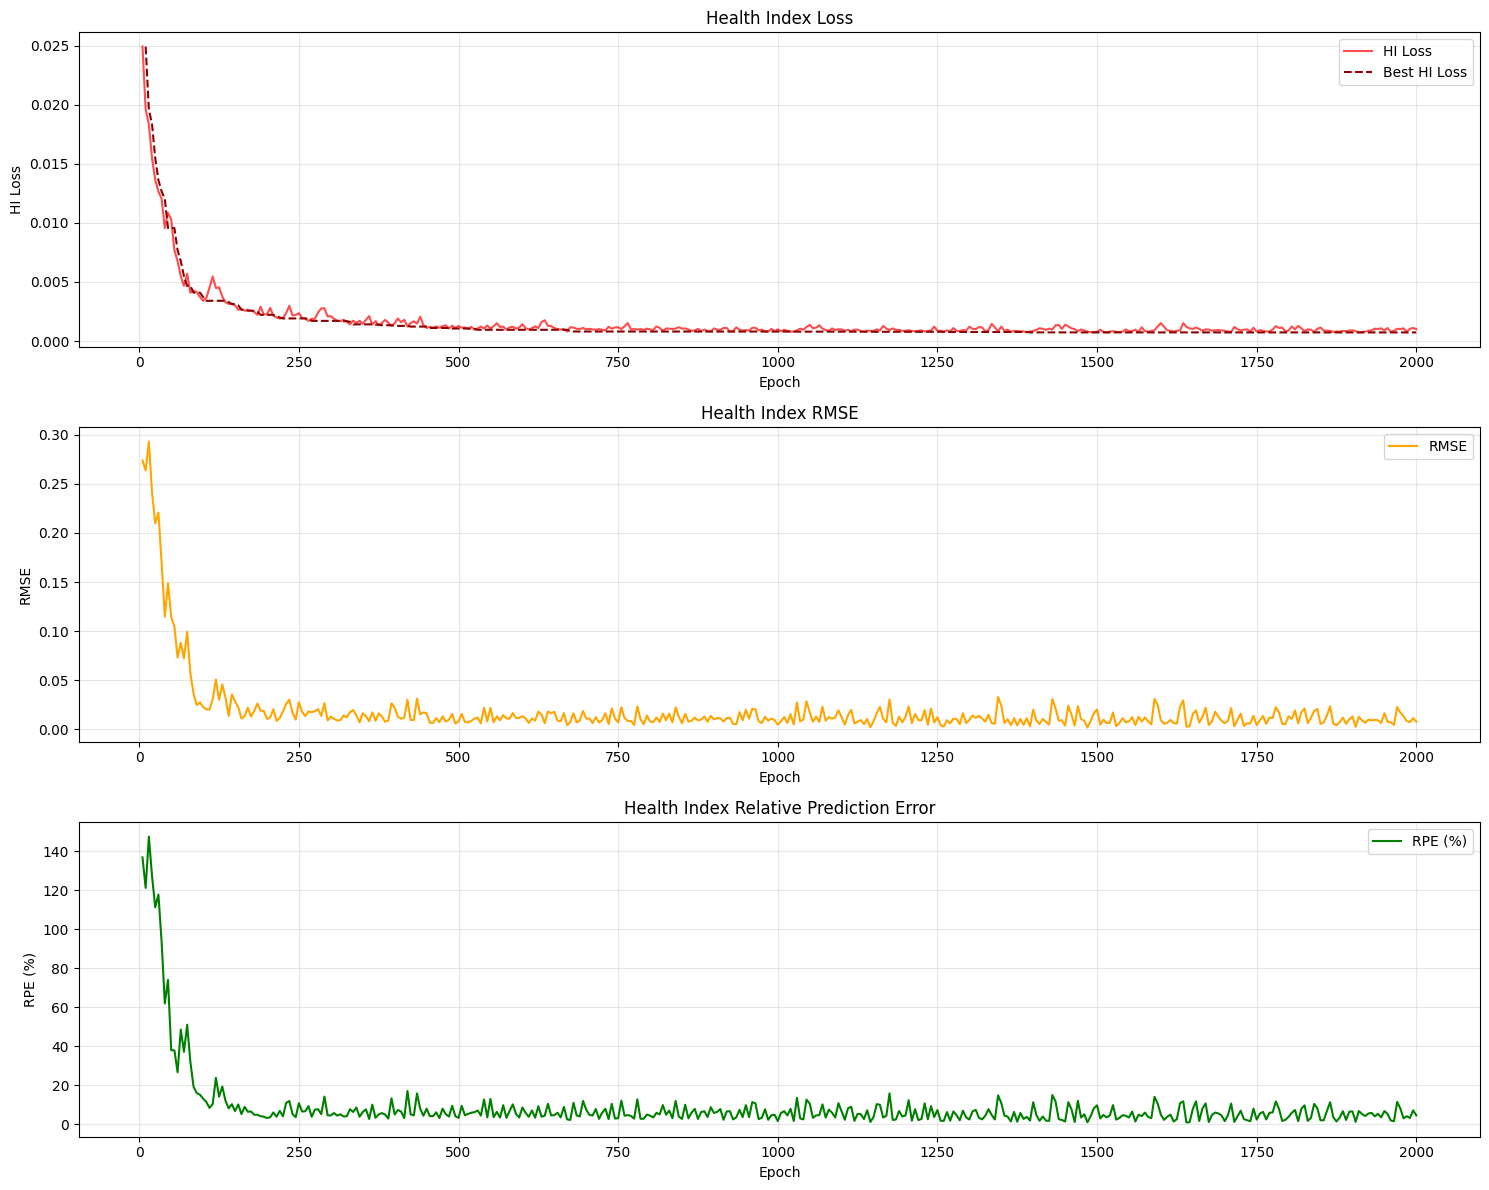


TRAINING SUMMARY
Total epochs logged: 400
Final HI Loss: 0.001013
Best HI Loss: 0.000729
Final HI RMSE: 0.0077
Final HI RPE: 4.57%


In [13]:
# Create training visualization for available HI metrics
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: HI Loss and Best HI Loss
axes[0].plot(training_log_df['epoch'], training_log_df['hi_loss'], label='HI Loss', color='red', alpha=0.7)
axes[0].plot(training_log_df['epoch'], training_log_df['best_hi_loss'], label='Best HI Loss', color='darkred', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('HI Loss')
axes[0].set_title('Health Index Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: HI RMSE
axes[1].plot(training_log_df['epoch'], training_log_df['hi_rmse'], label='RMSE', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Health Index RMSE')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: HI RPE
axes[2].plot(training_log_df['epoch'], training_log_df['hi_rpe'], label='RPE (%)', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('RPE (%)')
axes[2].set_title('Health Index Relative Prediction Error')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# Print training summary
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Total epochs logged: {len(training_log_df)}")
print(f"Final HI Loss: {training_log_df['hi_loss'].iloc[-1]:.6f}")
print(f"Best HI Loss: {training_log_df['best_hi_loss'].min():.6f}")
print(f"Final HI RMSE: {training_log_df['hi_rmse'].iloc[-1]:.4f}")
print(f"Final HI RPE: {training_log_df['hi_rpe'].iloc[-1]:.2f}%")
print("="*60)

Main

Test turning point index: 354

--- Overall Health Index Prediction Metrics ---
Total test samples: 524
Mean Squared Error (MSE):      0.000060
Root Mean Squared Error (RMSE):  0.007762
Mean Absolute Error (MAE):       0.004084
R-squared (R²):                  0.999265
Relative Prediction Error (RPE): 6.97%
Asymmetric Loss:                 0.000335


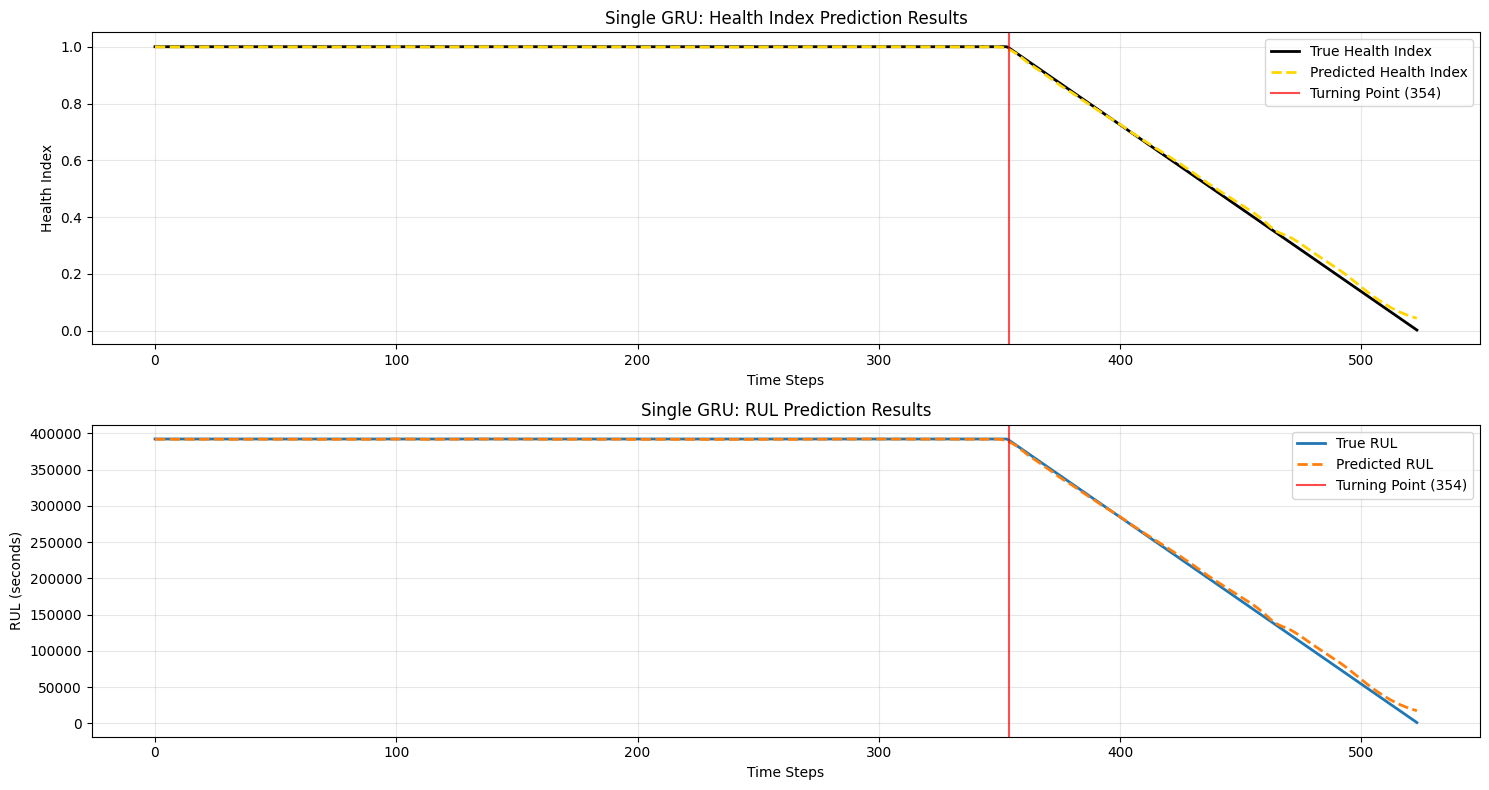


Results saved to: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_single_gru_results.csv
Evaluation metrics saved to: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_single_gru_eval_metrics.csv


In [14]:
# --- EVALUATION ---
hi_model.eval()

# Find test turning point
test_turning_point_idx = np.argmax(y_test_seq < 1.0) if np.any(y_test_seq < 1.0) else len(y_test_seq)
print(f"Test turning point index: {test_turning_point_idx}")

with torch.no_grad():
    # Get predictions for entire test set
    test_predictions_tensor = hi_model(X_test_tensor)
    test_predictions = test_predictions_tensor.cpu().numpy().flatten()
    y_true_test = y_test_tensor.cpu().numpy().flatten()

# --- Overall Performance Metrics ---
mse_overall = mean_squared_error(y_true_test, test_predictions)
rmse_overall = rmse_score(y_true_test, test_predictions)
mae_overall = mean_absolute_error(y_true_test, test_predictions)
r2_overall = r2_score(y_true_test, test_predictions)
rpe_overall = relative_prediction_error(y_true_test, test_predictions)
asymmetric_loss = asymmetric_loss_scoring_function(torch.from_numpy(test_predictions), torch.from_numpy(y_true_test))
asymmetric_loss = float(asymmetric_loss)

print("\n--- Overall Health Index Prediction Metrics ---")
print(f"Total test samples: {len(y_true_test)}")
print(f"Mean Squared Error (MSE):      {mse_overall:.6f}")
print(f"Root Mean Squared Error (RMSE):  {rmse_overall:.6f}")
print(f"Mean Absolute Error (MAE):       {mae_overall:.6f}")
print(f"R-squared (R²):                  {r2_overall:.6f}")
print(f"Relative Prediction Error (RPE): {rpe_overall:.2f}%")
print(f"Asymmetric Loss:                 {asymmetric_loss:.6f}")


# Visualization
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(y_true_test, label='True Health Index', linewidth=2, **PLOT_STYLES["HI"])
plt.plot(test_predictions, label='Predicted Health Index',**PLOT_STYLES["HI_PRED"], linewidth=2)
plt.axvline(x=test_turning_point_idx, **PLOT_STYLES["TP"], alpha=0.7, label=f'Turning Point ({test_turning_point_idx})')

plt.title('Single GRU: Health Index Prediction Results')
plt.xlabel('Time Steps')
plt.ylabel('Health Index')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(health_index_to_rul(y_true_test, BEARING_LIFESPAN_TIME), label='True RUL', linewidth=2)
plt.plot(health_index_to_rul(test_predictions, BEARING_LIFESPAN_TIME), label='Predicted RUL', linestyle='--', linewidth=2)
plt.axvline(x=test_turning_point_idx, **PLOT_STYLES["TP"], alpha=0.7, label=f'Turning Point ({test_turning_point_idx})')
plt.title('Single GRU: RUL Prediction Results')
plt.xlabel('Time Steps')
plt.ylabel('RUL (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Export results
results_df = pd.DataFrame({
    'time_step': np.arange(len(y_true_test)),
    'true_health_index': y_true_test,
    'predicted_health_index': test_predictions,
    'true_rul': health_index_to_rul(y_true_test, BEARING_LIFESPAN_TIME),
    'predicted_rul': health_index_to_rul(test_predictions, BEARING_LIFESPAN_TIME)
})
results_path = f"{_func(MAIN_BEARING)}_single_gru_results.csv"
results_df.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")

# Export evaluation metrics
eval_metrics_df = pd.DataFrame([{
    'model': 'single_gru',
    'turning_point_true_idx': test_turning_point_idx,
    'samples_total': len(y_true_test),
    'hi_mse': mse_overall,
    'hi_rmse': rmse_overall,
    'hi_mae': mae_overall,
    'hi_r2': r2_overall,
    'hi_rpe': rpe_overall,
    'hi_asymmetric_loss': asymmetric_loss
}])
eval_metrics_path = f"{_func(MAIN_BEARING)}_single_gru_eval_metrics.csv"
eval_metrics_df.to_csv(eval_metrics_path, index=False)
print(f"Evaluation metrics saved to: {eval_metrics_path}")